# Imputation for Individual Rivers using Machine Learning Methods 

In [4]:
# read in the data 
import pandas as pd
rivers = pd.read_csv('/Users/ratrag/Library/CloudStorage/OneDrive-Personal/Maastricht Study/Semester 1/Research Project S2/Lake Tanganyika/Lake-Tanganyika/data/outputs/master_dataset_inputed.csv')
rivers_original = rivers.copy()

# sanity check 
print(rivers.head())
print(rivers.info())
print(rivers.describe())


rivers["date"] = pd.to_datetime(rivers[["year", "month"]].assign(day=1))
rivers_original["date"] = pd.to_datetime(rivers_original[["year", "month"]].assign(day=1))

rivers = rivers.sort_values("date").set_index("date")
rivers_original = rivers_original.sort_values("date").set_index("date")

     river        date  year  month  water_level  runoff  temp_max_observed  \
0  Buzimba  1981-01-01  1981      1     0.541000   16.94          26.619355   
1  Buzimba  1981-02-01  1981      2     0.485000   15.35          26.696429   
2  Buzimba  1981-03-01  1981      3     0.548387   17.96          26.087097   
3  Buzimba  1981-04-01  1981      4     0.648000   13.90          26.093333   
4  Buzimba  1981-05-01  1981      5     0.594194   10.83          25.896774   

   temp_min_observed  precip_observed        temp_source  ... era5_t2m_max  \
0           17.38424       154.966725  NYANZA LAC (IRAT)  ...     24.52773   
1           17.38900       120.119005  NYANZA LAC (IRAT)  ...     26.76890   
2           18.16450       126.911998  NYANZA LAC (IRAT)  ...     25.12410   
3           18.14420       117.792010  NYANZA LAC (IRAT)  ...     24.81442   
4           17.22097       117.313940  NYANZA LAC (IRAT)  ...     25.68795   

  era5_tp_sum  era5_u10_mean  era5_v10_mean  era5_d2m_me

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# store original rivers data (for plotting later)
rivers_original = rivers.copy()


# features to use for imputation
X_cols = [
    "runoff",
    "temp_max_observed",
    "temp_min_observed",
    "precip_observed"
]


# models: linear, ridge, lasso, random forest
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}


# results storage
results = []


# loop per river
for river_name in rivers["river"].unique():

    df = rivers[rivers["river"] == river_name]

    # split known vs missing
    train_df = df[df["water_level"].notna()]
    missing_df = df[df["water_level"].isna()]

    # skip small datasets
    if len(train_df) < 50:
        continue

    X_train = train_df[X_cols]
    y_train = train_df["water_level"]

    X_missing = missing_df[X_cols]

    # impute predictors
    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    X_missing_imp = imputer.transform(X_missing)

    
    # loop per model
    for name, model in models.items():

        # train on full training data
        model.fit(X_train_imp, y_train)

        # impute missing values
        if len(X_missing_imp) > 0:

            preds_missing = model.predict(X_missing_imp)

            col_name = f"water_level_{name}"

            # initialize column if needed
            if col_name not in rivers.columns:
                rivers[col_name] = rivers["water_level"]

            # fill only missing values
            rivers.loc[
                (rivers["river"] == river_name) & (rivers["water_level"].isna()),
                col_name
            ] = preds_missing

        # evaluation (time-aware split)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_imp, y_train, test_size=0.2, shuffle=False
        )

        model.fit(X_tr, y_tr)
        preds_val = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds_val))
        mae = mean_absolute_error(y_val, preds_val)

        results.append({
            "river": river_name,
            "model": name,
            "rmse": rmse,
            "mae": mae
        })


# results table
results_df = pd.DataFrame(results)

print("\n=== Full Results ===")
print(results_df)

# best model per river
best_models = results_df.loc[
    results_df.groupby("river")["rmse"].idxmin()
]

best_models = best_models.rename(columns={"model": "best_model"})

print("\n=== Recommended Imputation Method per River ===")
print(best_models[["river", "best_model", "rmse", "mae"]].sort_values("river"))


# overall performance
summary = results_df.groupby("model")[["rmse", "mae"]].mean()

print("\n=== Average Performance Across Rivers ===")
print(summary.sort_values("rmse"))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['runoff']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['runoff']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['runoff']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['r


=== Full Results ===
         river         model      rmse       mae
0      Buzimba        Linear  0.705439  0.655197
1      Buzimba         Ridge  0.705224  0.655015
2      Buzimba         Lasso  0.699111  0.650444
3      Buzimba  RandomForest  0.741445  0.681156
4    Nyamagana        Linear  0.295187  0.263013
5    Nyamagana         Ridge  0.295124  0.262956
6    Nyamagana         Lasso  0.287029  0.255904
7    Nyamagana  RandomForest  0.345312  0.304365
8      Nyengwe        Linear  0.445147  0.319581
9      Nyengwe         Ridge  0.445173  0.319622
10     Nyengwe         Lasso  0.446540  0.321920
11     Nyengwe  RandomForest  0.487176  0.345127
12      Rusizi        Linear  1.667935  1.598352
13      Rusizi         Ridge  1.667980  1.598476
14      Rusizi         Lasso  1.643631  1.574089
15      Rusizi  RandomForest  1.639870  1.556871
16        Jiji        Linear  0.173489  0.143120
17        Jiji         Ridge  0.173464  0.143098
18        Jiji         Lasso  0.172604  0.14245


===== Linear Imputation =====


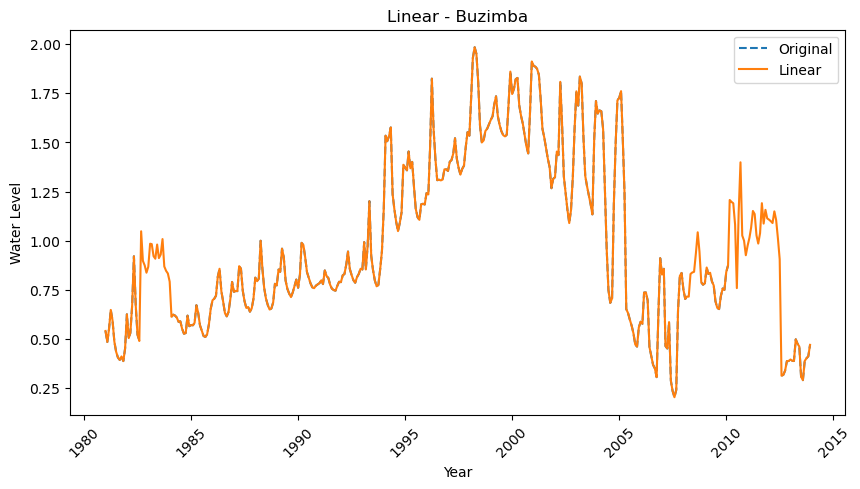

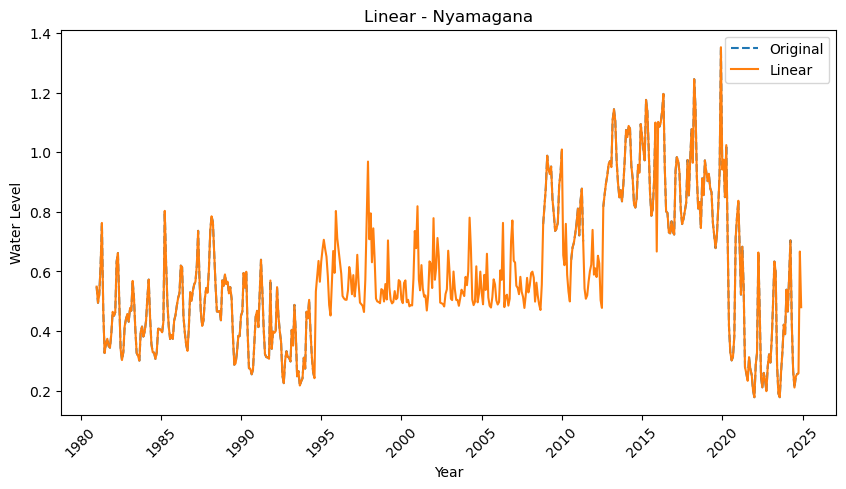

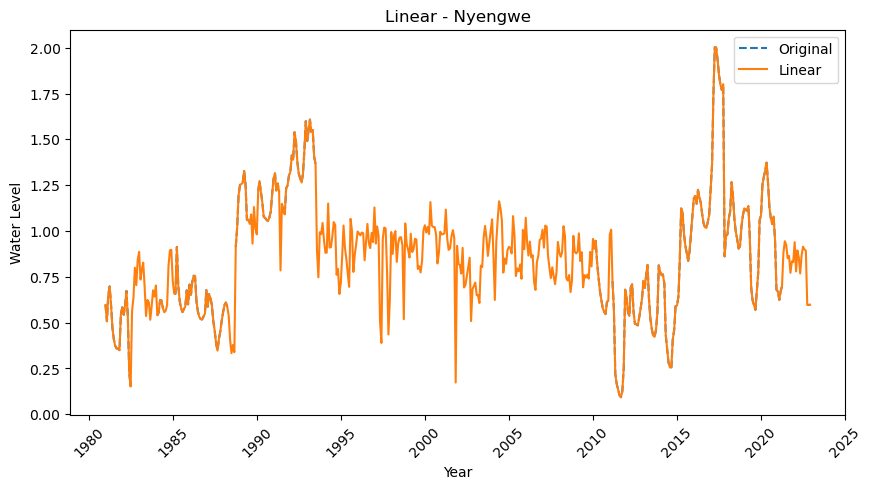

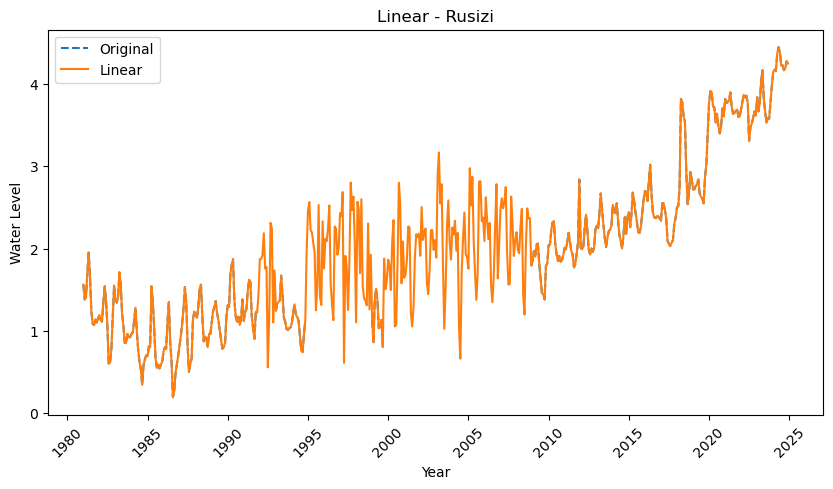

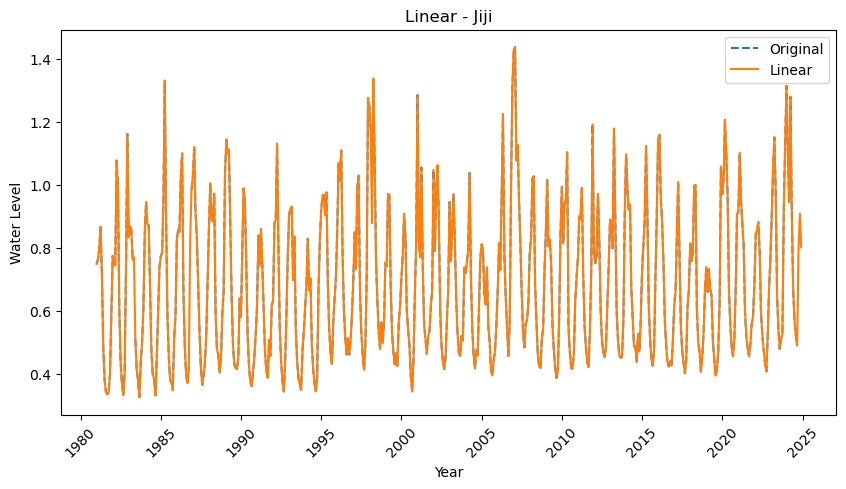

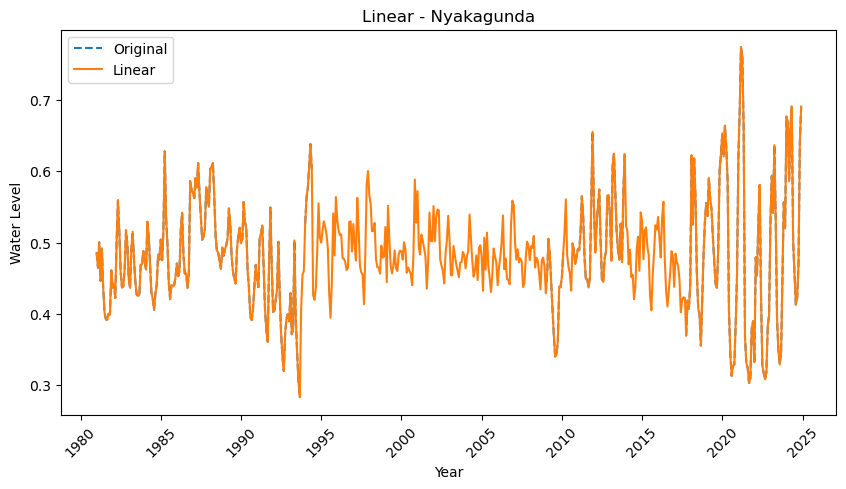

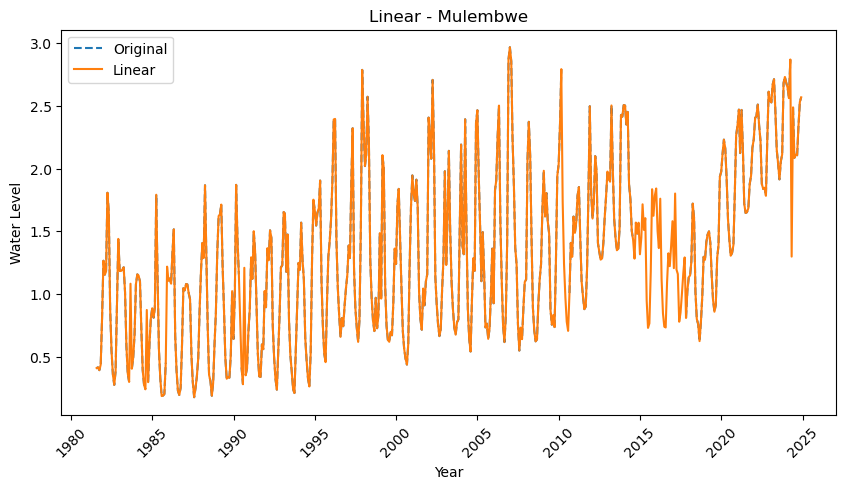

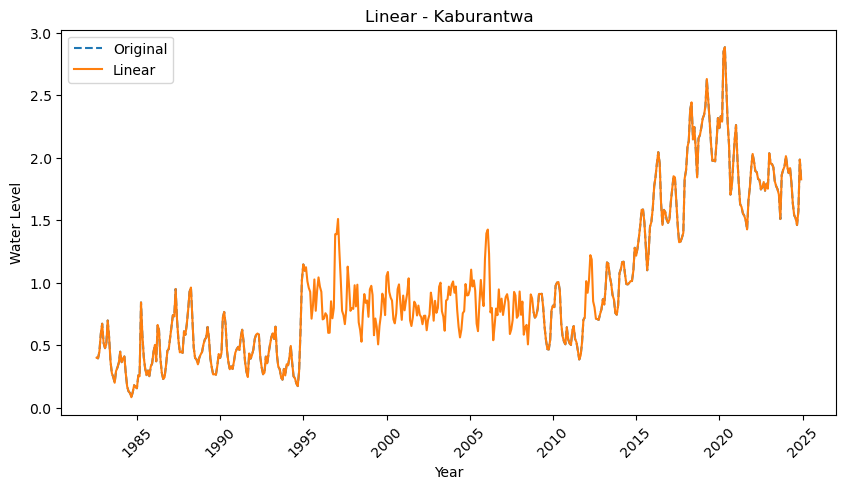

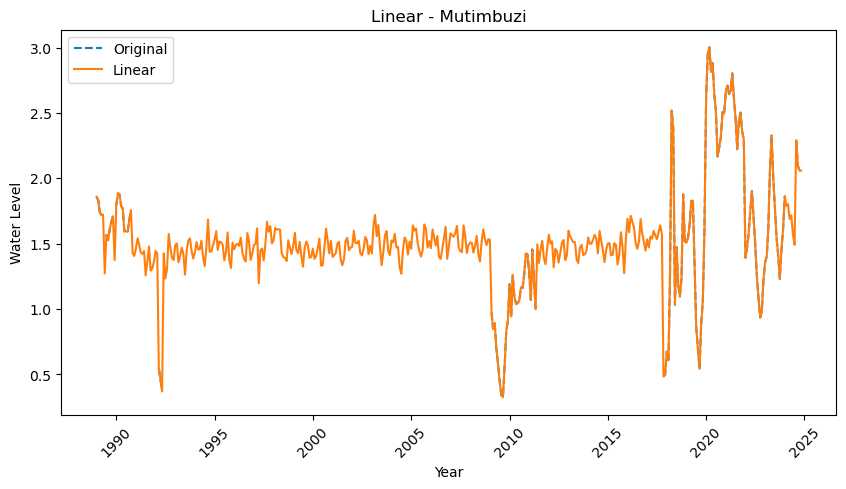

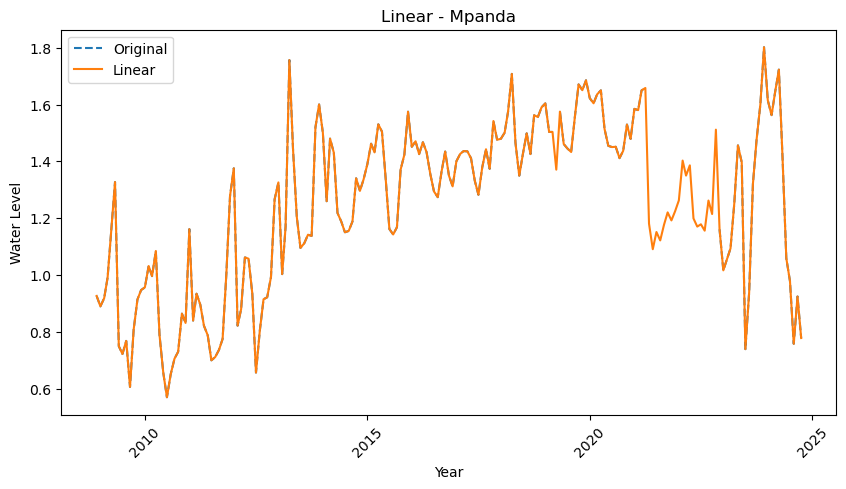


===== Ridge Imputation =====


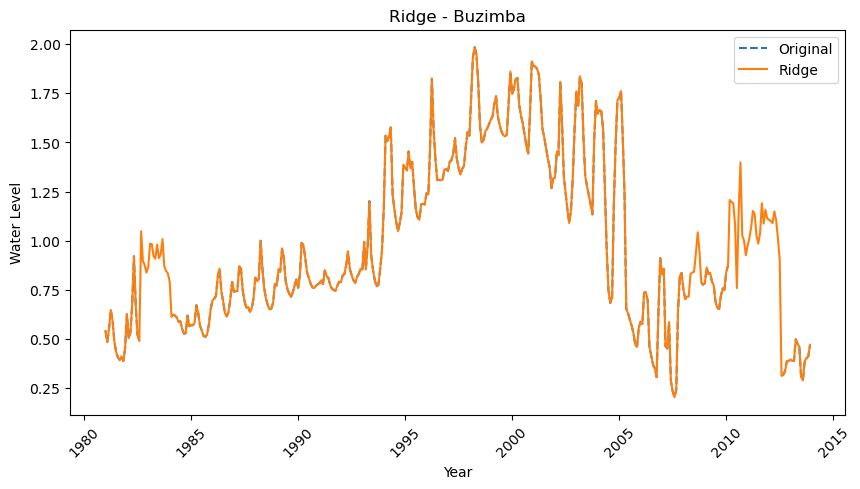

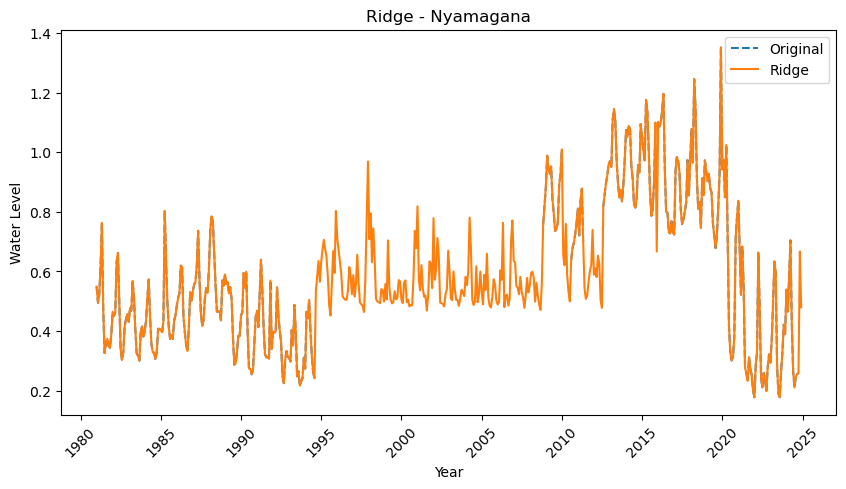

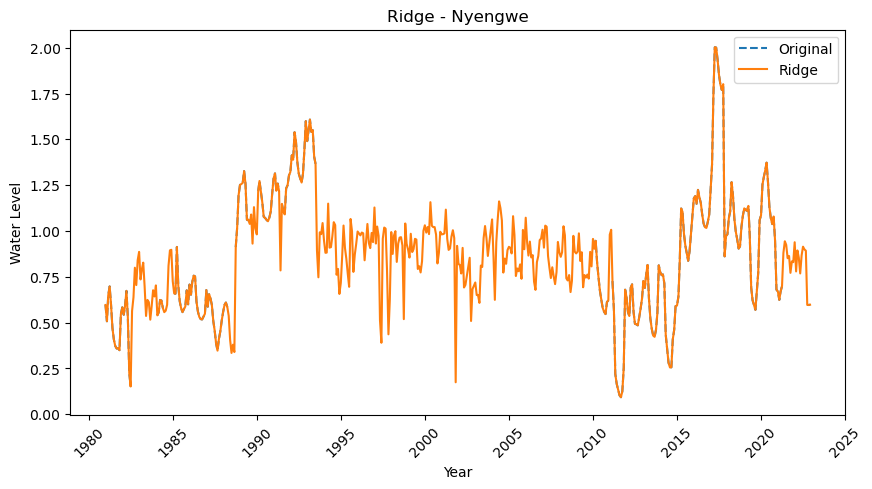

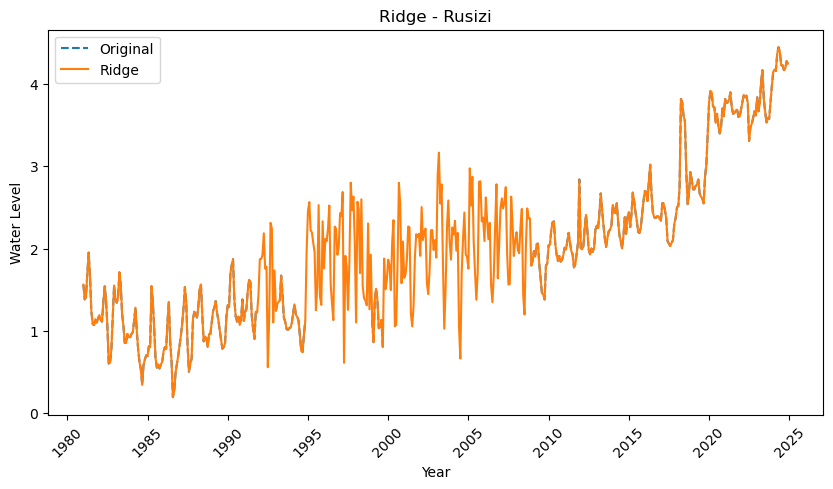

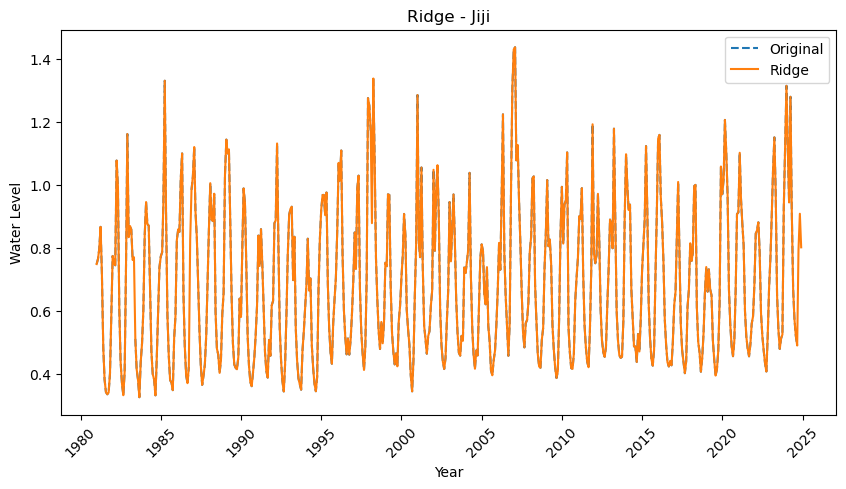

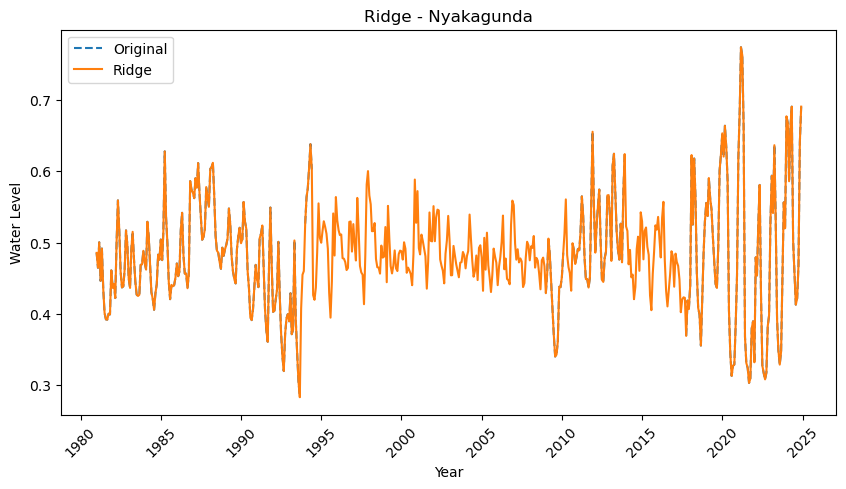

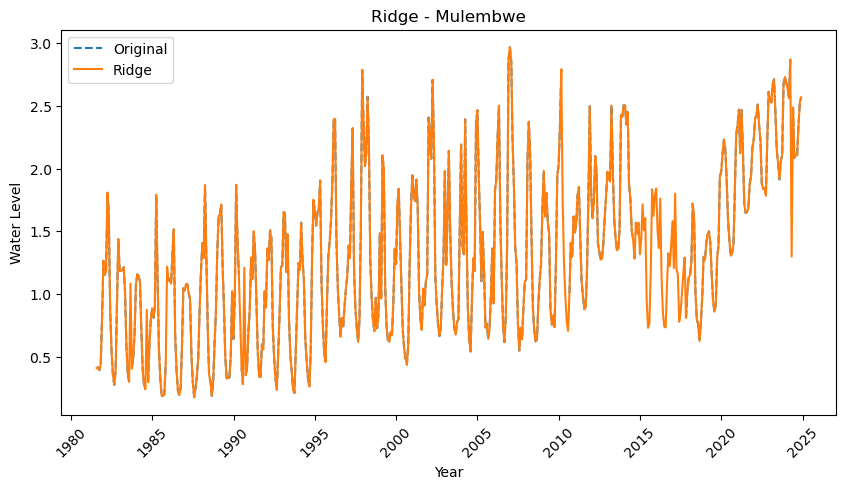

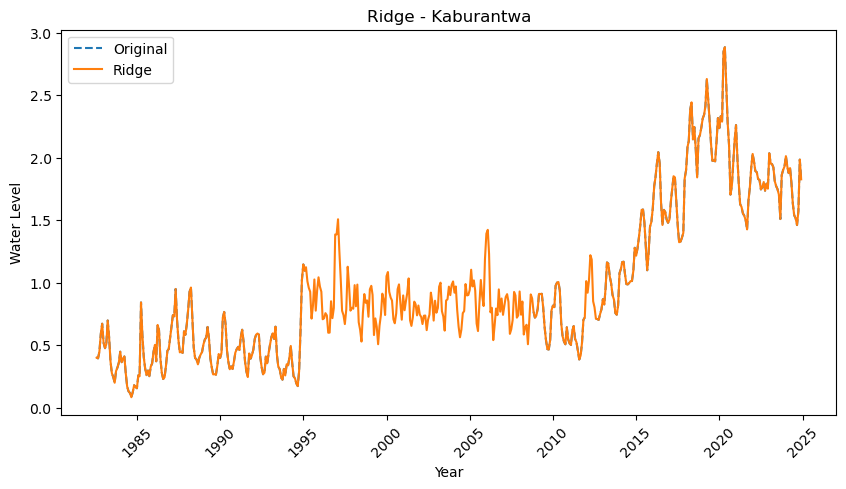

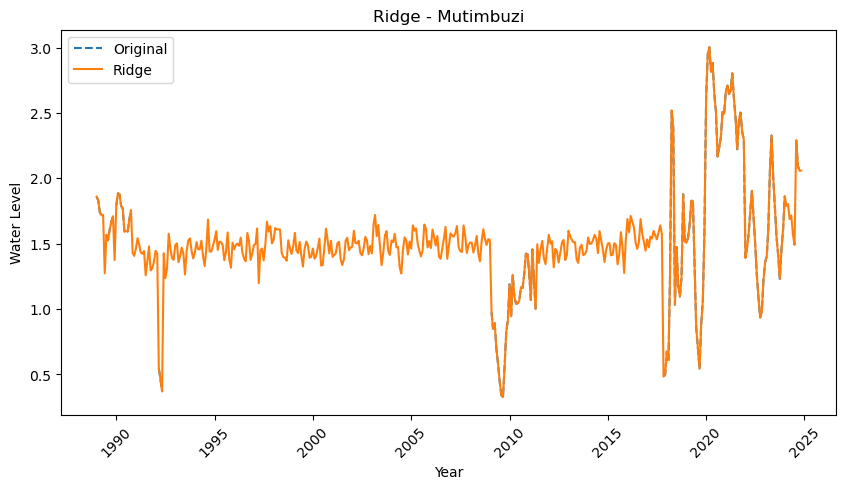

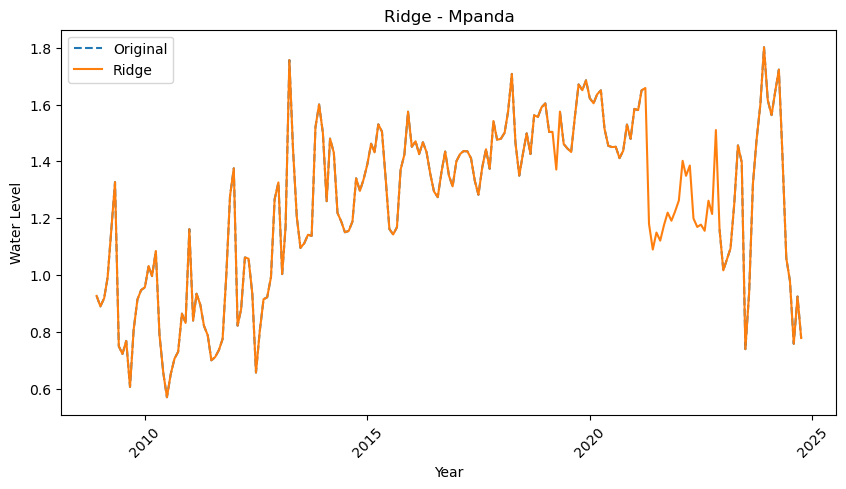


===== Lasso Imputation =====


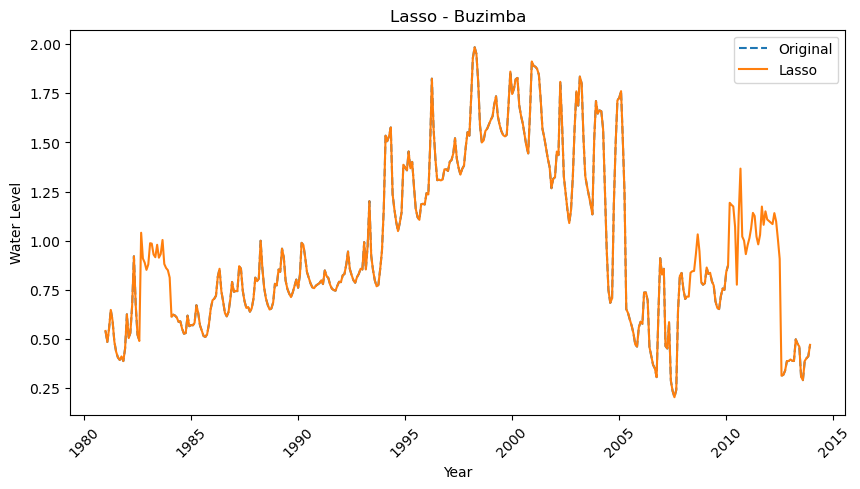

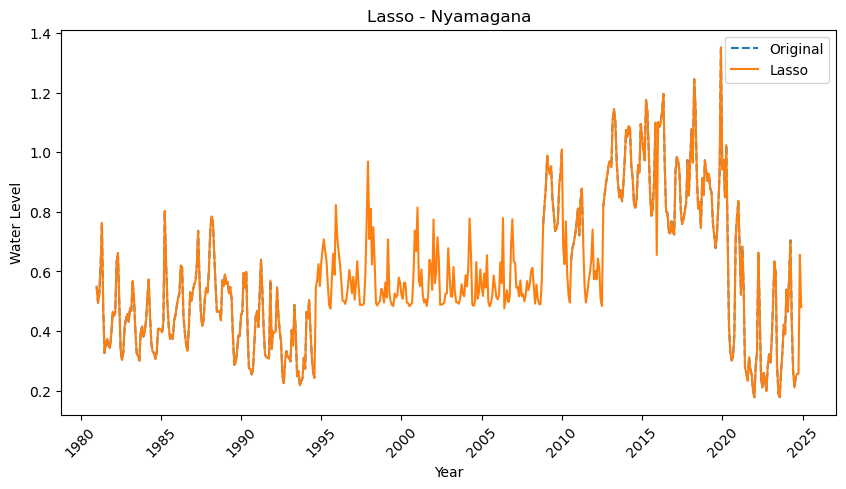

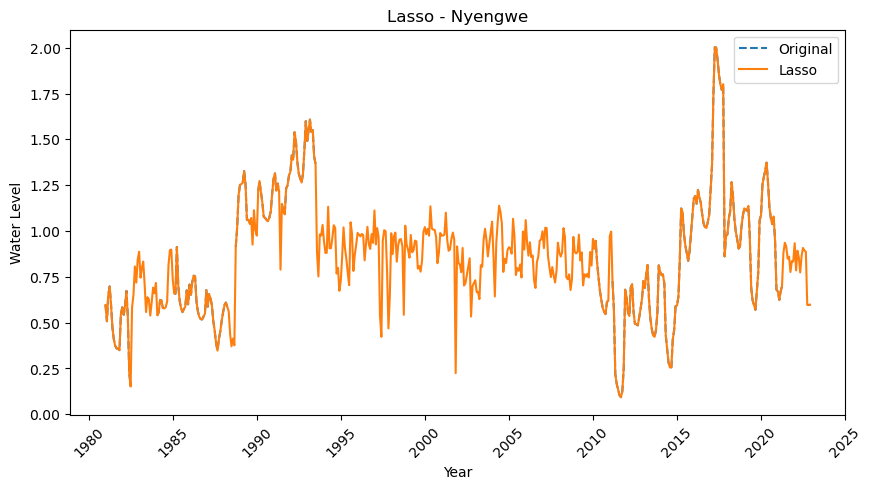

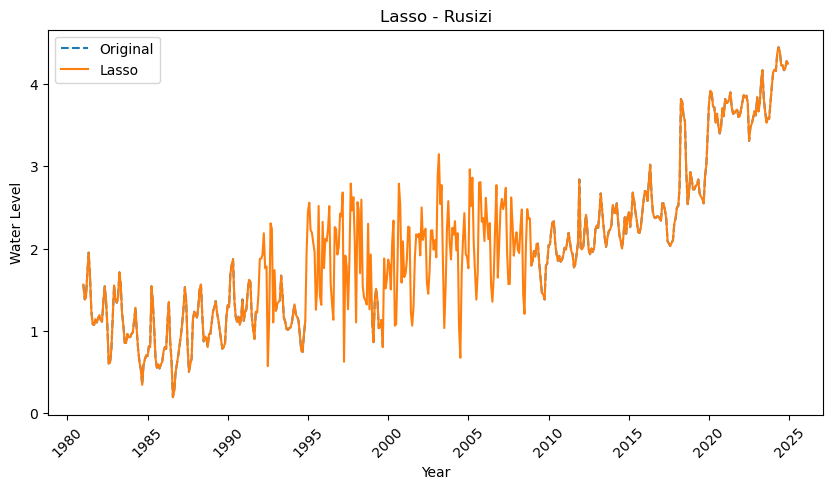

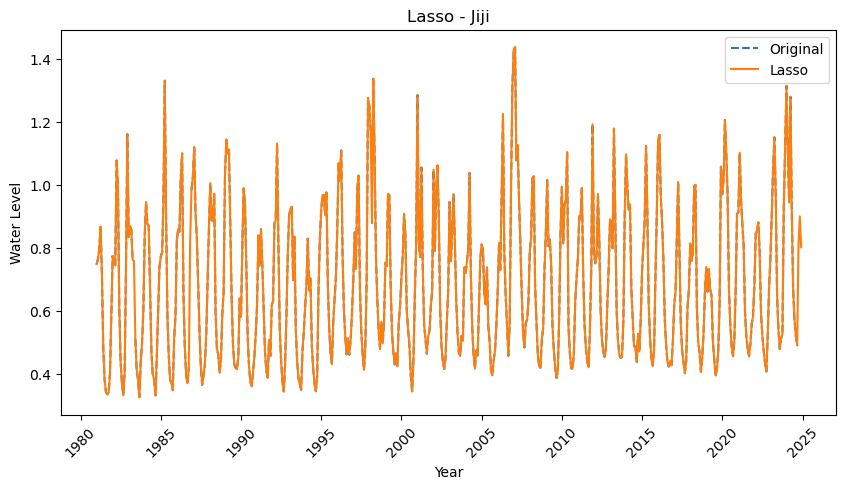

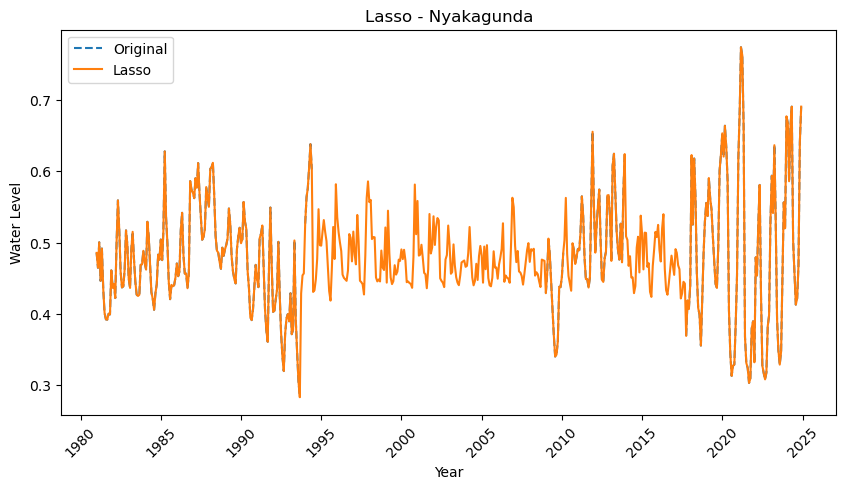

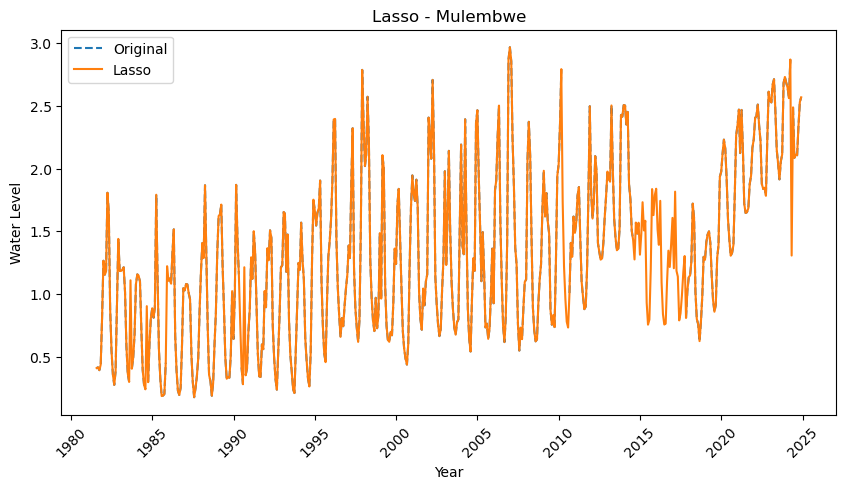

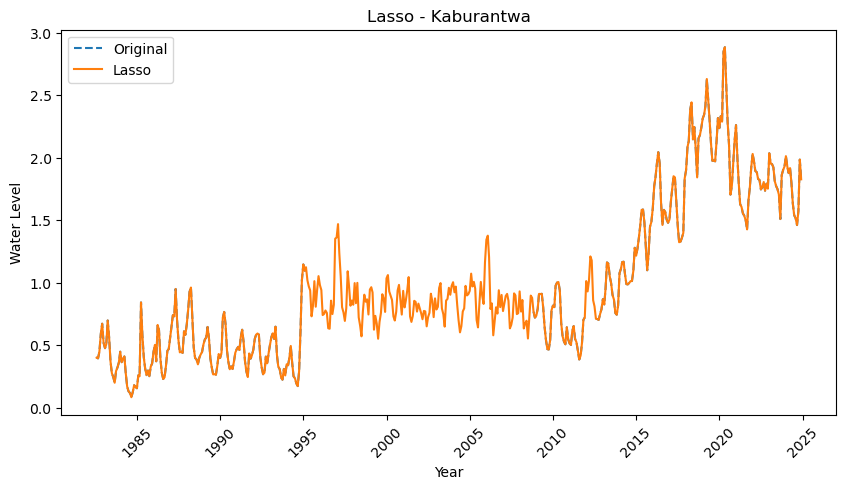

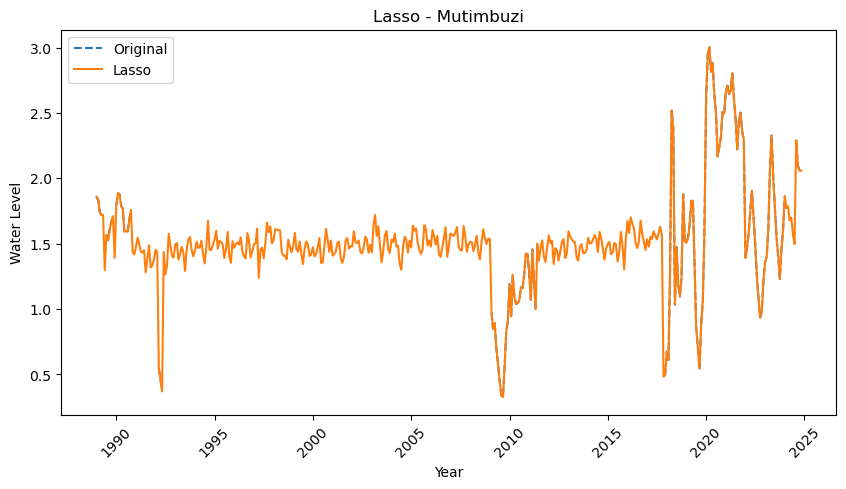

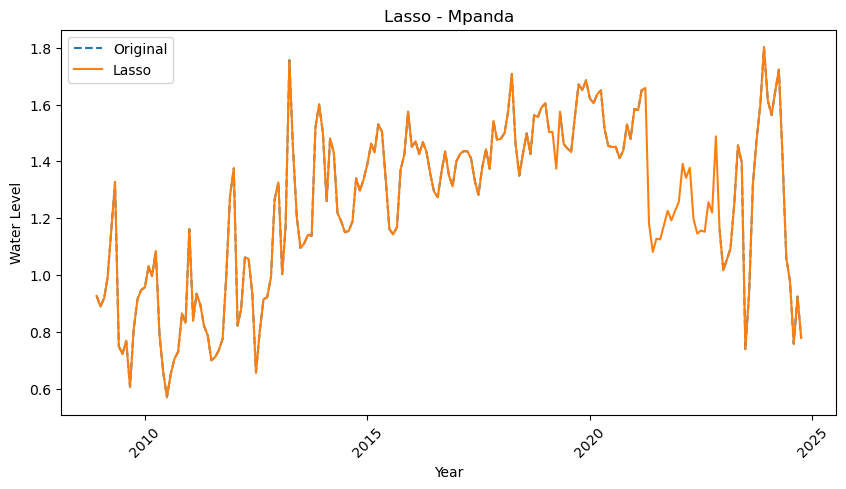


===== RandomForest Imputation =====


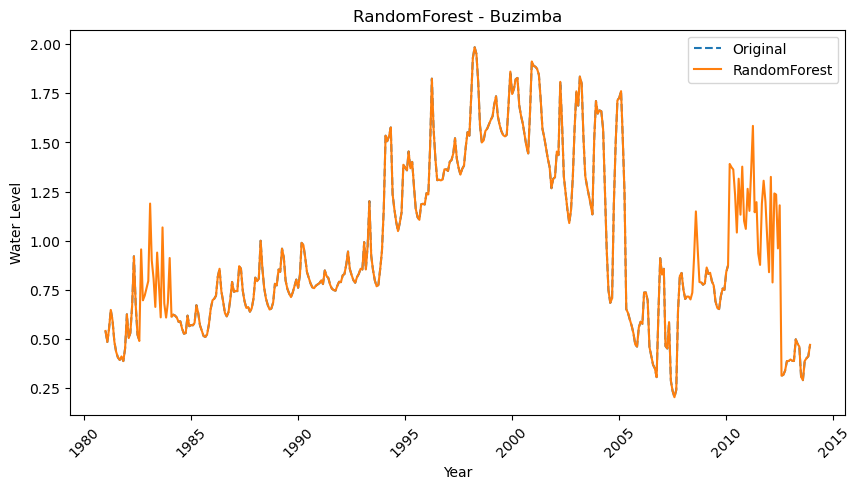

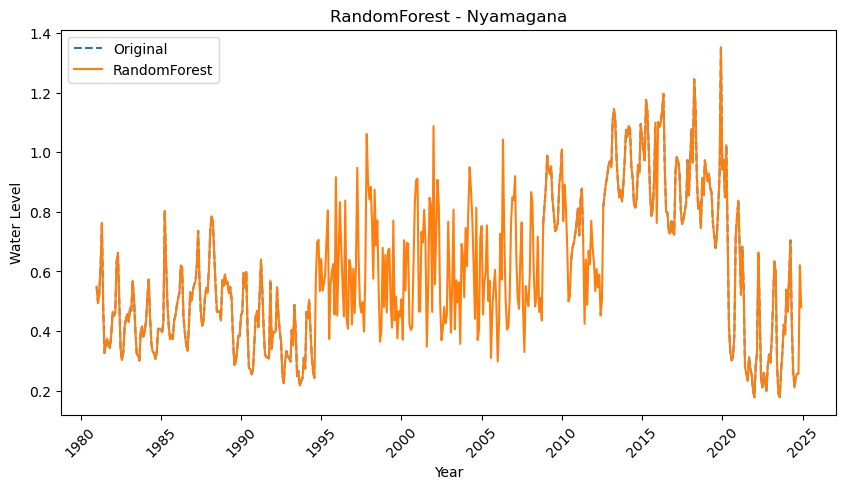

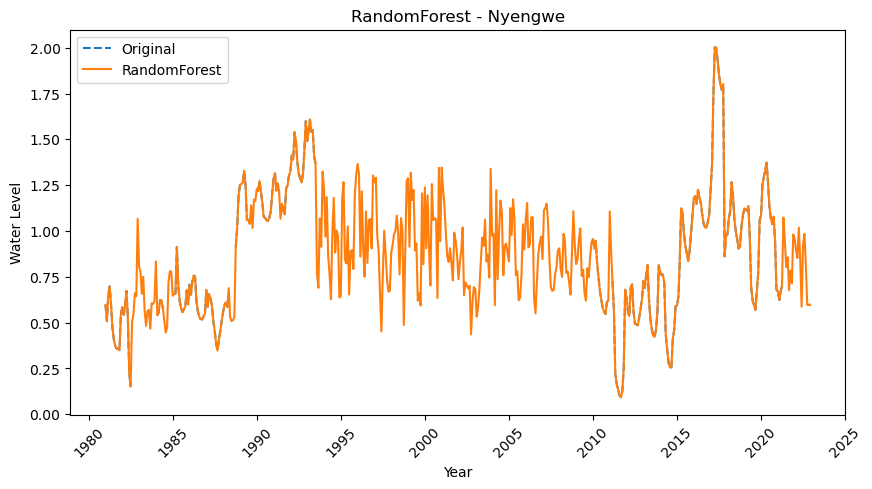

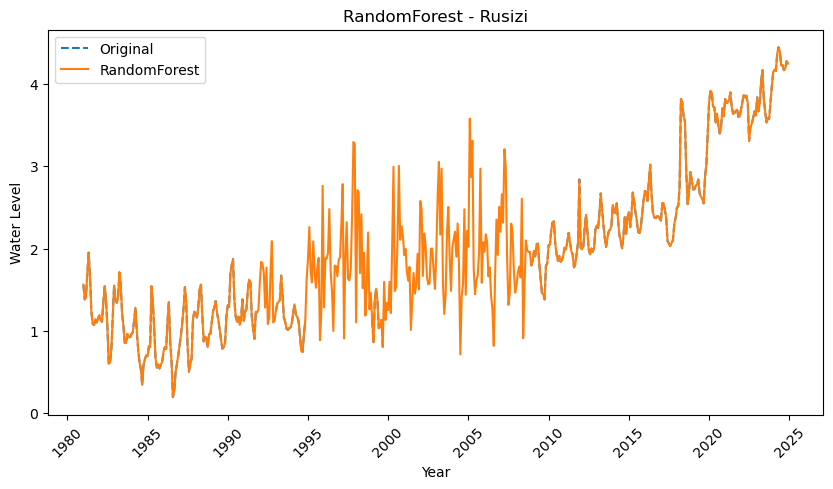

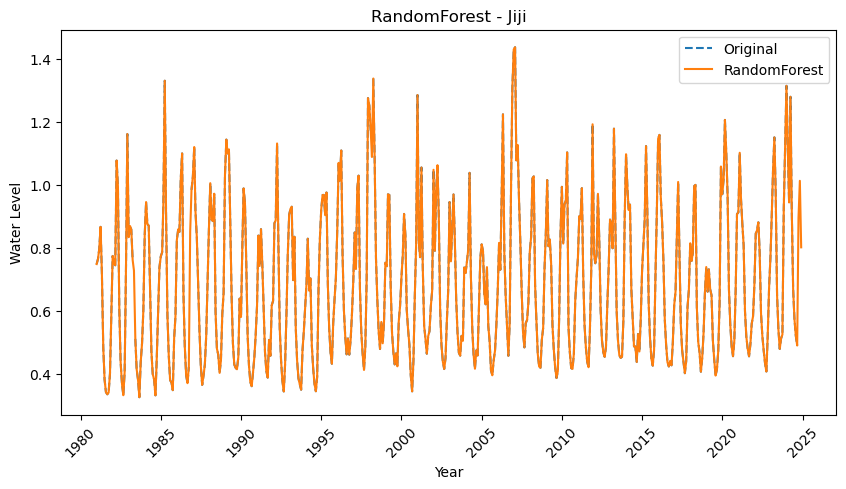

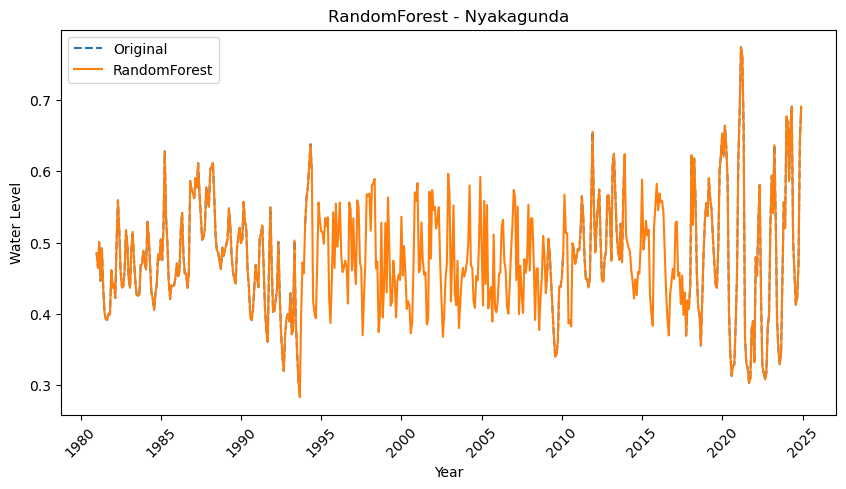

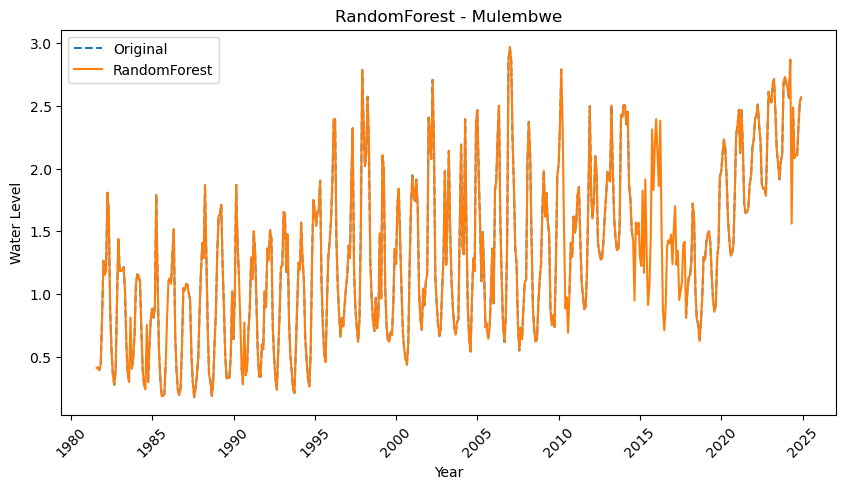

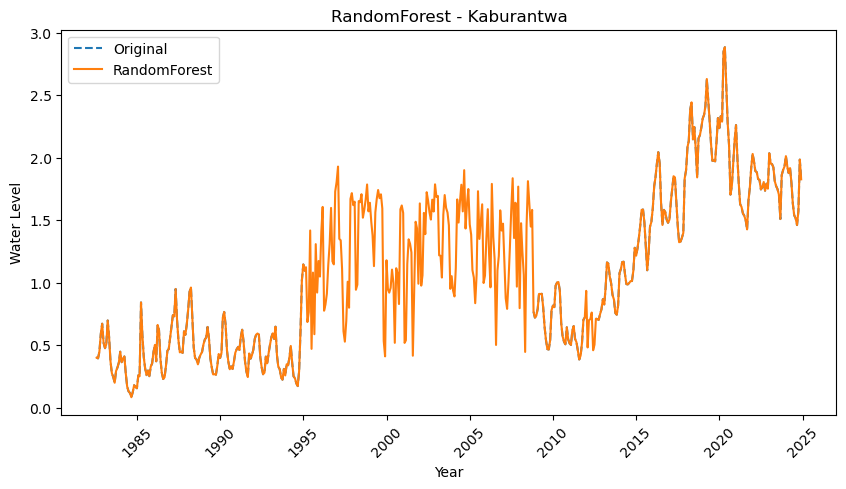

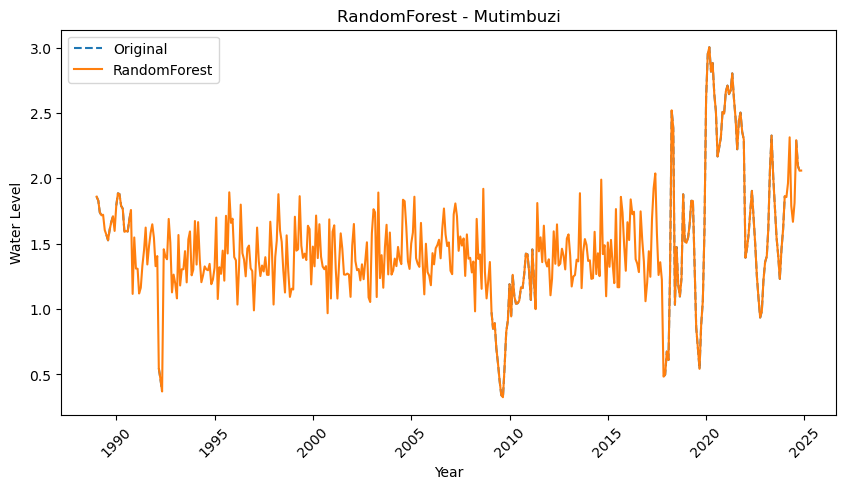

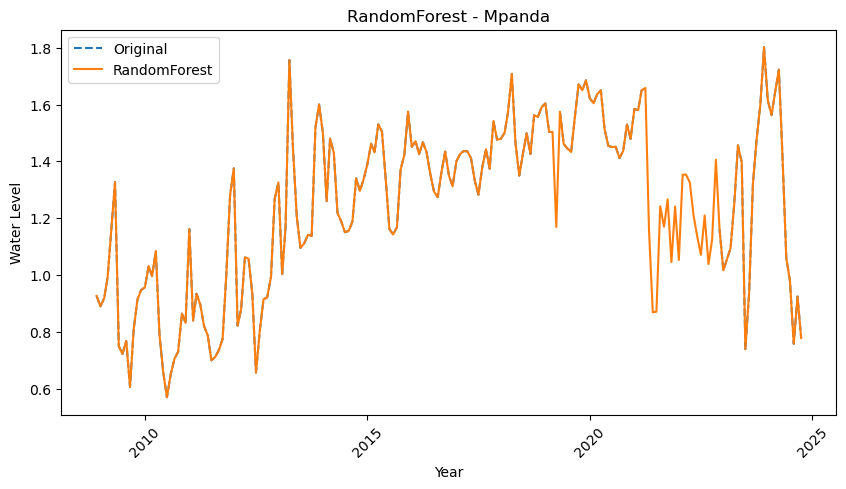

In [ ]:
# plotting imputed vs original for each model and river
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

model_names = ["Linear", "Ridge", "Lasso", "RandomForest"]

for model_name in model_names:

    print(f"\n===== {model_name} Imputation =====")

    for river_name in rivers["river"].unique():

        df = rivers[rivers["river"] == river_name]
        df_orig = rivers_original[rivers_original["river"] == river_name]

        col_name = f"water_level_{model_name}"

        if col_name not in df.columns:
            continue

        plt.figure(figsize=(10, 5))

        # original (with gaps)
        plt.plot(
            df.index,
            df_orig["water_level"],
            linestyle="--",
            label="Original"
        )

        # imputed for this model
        plt.plot(
            df.index,
            df[col_name],
            label=f"{model_name}"
        )

        # format x-axis (every 5 years)
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.xticks(rotation=45)

        plt.title(f"{model_name} - {river_name}")
        plt.xlabel("Year")
        plt.ylabel("Water Level")
        plt.legend()

        plt.show()